#### Assignment #1 - Part 1 - Average Salary of Teachers in Chicago
-   Data cleansing 
-   Select the right rows for teachers 
-   Delete na values or impute 
-   Winsorze for outliers and compute summary stats

In [90]:
import pandas as pd
import numpy as np
from scipy.stats import mstats
import matplotlib.pyplot as plt

In [72]:
sal = pd.read_excel(r"data\\EmployeePositionRoster_06302023.xlsx")
print('Date shape:',sal.shape)
print('Data Columns:',sal.columns)

Date shape: (45070, 11)
Data Columns: Index(['Pos #', 'Dept ID', 'Department', 'FTE', 'ClsIndc', 'Annual Salary',
       'FTE Annual Salary', 'Annual Benefit Cost', 'JobCode', 'Job Title',
       'Name'],
      dtype='object')


In [75]:
# more than 1019 job types, how many teachers? 
print ('Numbe of rows in data:',sal.shape[0])
job_titles = sal['Job Title'].unique()
print('Number of different job titles :', job_titles.shape[0])

# atleast half the dataset is teachers, makes sense as well 
teacher_titles = [x for x in job_titles if 'teacher' in x.lower()]
print ('Number of job codes with teacher keyword in it:',len(teacher_titles))
teachers = sal[sal['Job Title'].isin(teacher_titles)]
print("Number of rows with teacher in job title:",teachers.shape[0])

Numbe of rows in data: 45070
Number of different job titles : 1019
Number of job codes with teacher keyword in it: 27
Number of rows with teacher in job title: 22448


<Axes: >

<Axes: >

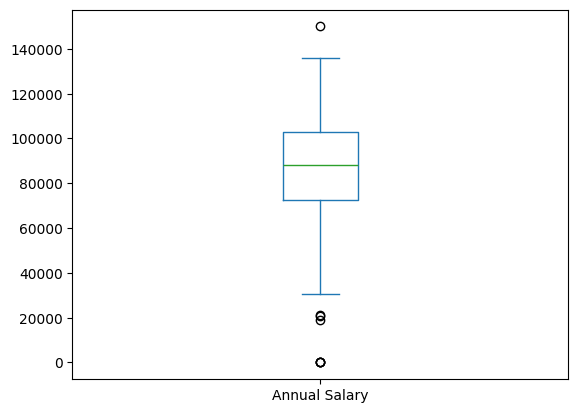

In [76]:
# Start with distribution - I see 0 as salary and then some more outliers 
teachers['Annual Salary'].plot(kind='box')

In [77]:
# Check NA first and either delte or impute with med / mean
# Next see who is working for free? at 0$ 
# Last check for any outliers / winsorize
missing_salary_pct = (teachers["Annual Salary"].isna().sum() / teachers.shape[0]) * 100
print('% of teachers missing salary in data:',missing_salary_pct.round(2),'%')

# less than 10% data - I am happy to remove nulls as I dont have data to be biased to mean / median
teachers_nonull = teachers[~teachers["Annual Salary"].isna()]
print('Total rows in teachers :', teachers.shape[0])
print('Number of rows after removing null:',teachers_nonull.shape[0])



% of teachers missing salary in data: 8.06 %
Total rows in teachers : 22448
Number of rows after removing null: 20639


In [84]:
# 4 teachers working with 0 salary - now either remove these or impute  
# 4 values I can safely delete rows
print('Number of teachers with 0$ salary:', (teachers_nonull[teachers_nonull['Annual Salary'] == 0].shape[0]))
teachers_nonull = teachers_nonull[teachers_nonull['Annual Salary'] != 0]
print('Number of rows after removing 0$ salary:',teachers_nonull.shape[0])

Number of teachers with 0$ salary: 0
Number of rows after removing 0$ salary: 20635


<Axes: >

<Axes: >

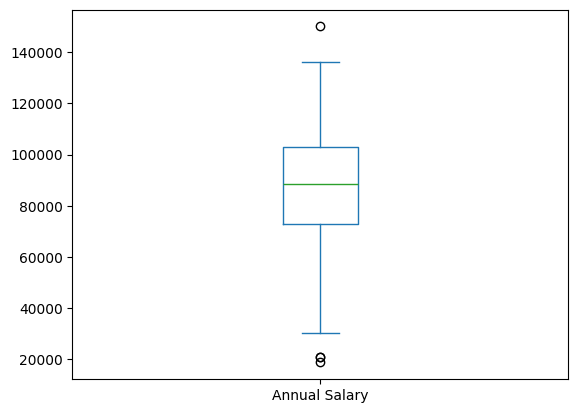

In [86]:
teachers_nonull['Annual Salary'].plot(kind='box')
# notice few outliers, we can winsorize at 99.75 and 0.25


<Axes: >

<Axes: >

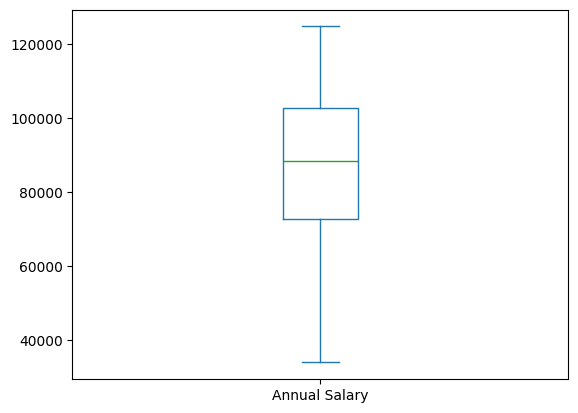

In [89]:
# Winsorize Annual Salary at 0.25% and 99.75%
teachers_clean = teachers_nonull.copy()
winsorized_values = mstats.winsorize(teachers_clean['Annual Salary'], limits=[0.0025, 0.0025])
teachers_clean['Annual Salary'] = winsorized_values
teachers_clean['Annual Salary'].plot(kind='box')

c:\Users\abhis\git\mas\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4779: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


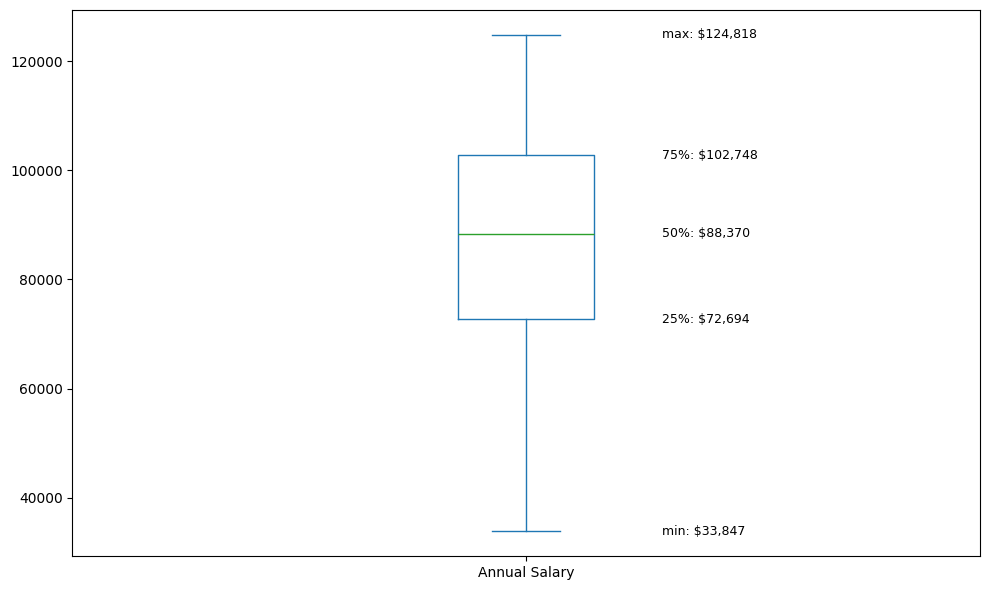

Five-Number Summary for Teacher Salaries (Winsorized):
min     33847.0
25%     72694.0
50%     88370.0
75%    102748.0
max    124818.0
Name: Annual Salary, dtype: float64


In [91]:
# get summary now and final box plot with labels
fig, ax = plt.subplots(figsize=(10, 6))
teachers_clean['Annual Salary'].plot(kind='box', ax=ax)

# Get five-number summary
q_values = teachers_clean['Annual Salary'].describe()[['min', '25%', '50%', '75%', 'max']]

# Add text annotations for each level, y value will match as that is what we are plotting
for i, (label, value) in enumerate(q_values.items()):
    ax.text(1.15, value, f'{label}: ${value:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Five-Number Summary for Teacher Salaries (Winsorized):')
print(q_values)

--- Ranked 'Nice' Bin Widths ---
   Power (p)  Bin Width  Number of Bins  Cost (C)
0          3     5000.0              27 -0.035051
1          4    10000.0              14 -0.029899
2          4    12500.0              11 -0.023567

Best 'Nice' Choice: Width = $5,000 (Bins: 27.0)


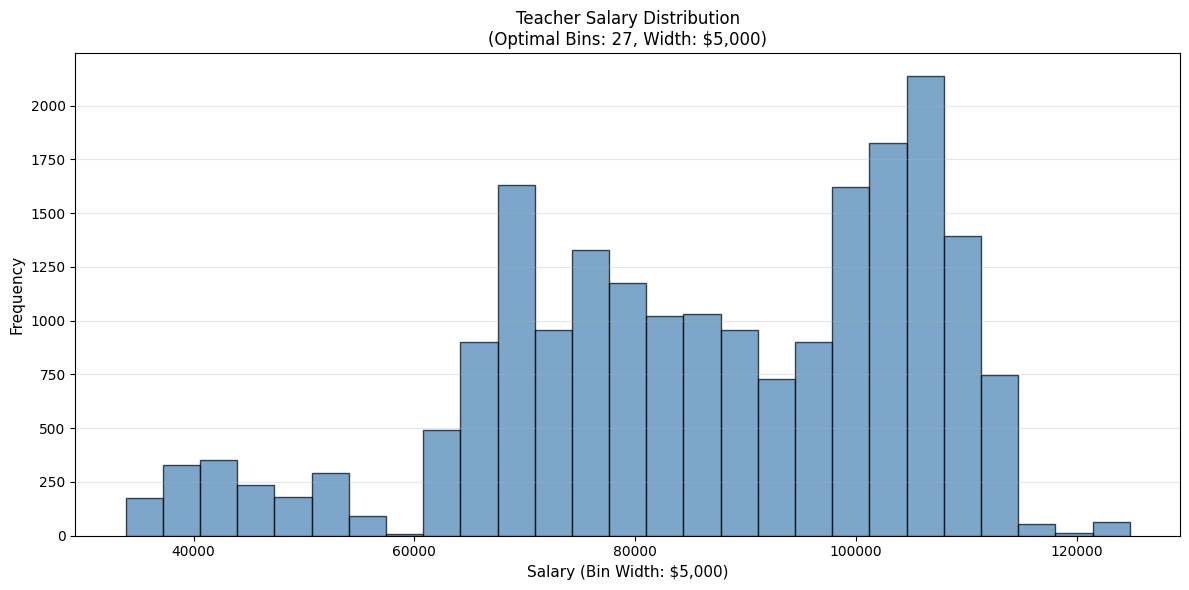

Histogram plotted with optimal bin width: $5,000
Number of bins: 27


In [94]:


salaries = teachers_nonull['Annual Salary']
data_min = np.min(salaries)
data_max = np.max(salaries)
data_range = data_max - data_min

# 2. Define the "Nice Number" Candidates
base_candidates = [1, 1.25, 2, 2.5, 5]
powers_to_try = [3, 4] # Based on "Common Sense" for salaries (1k to 50k range)

nice_widths = []
for p in powers_to_try:
    for base in base_candidates:
        nice_widths.append(base * (10**p))

# 3. Evaluate Each "Nice" Width
results = []

for width in nice_widths:
    # Calculate number of bins for this width
    n_bins = int(np.ceil(data_range / width))
    
    # CONSTRAINT: Only consider if bins are between 10 and 50
    if 10 <= n_bins <= 50:
        
        # Shimazaki Cost Calculation
        edges = np.arange(data_min, data_max + width, width) # Create edges
        k, _ = np.histogram(salaries, bins=edges) # Count freq
        k_mean = np.mean(k)
        v = np.var(k)
        
        # The Cost Function
        C = (2 * k_mean - v) / (width ** 2)
        
        results.append({
            "Power (p)": np.log10(width/base_candidates[0] if width in base_candidates else width).astype(int), # approx p
            "Bin Width": width,
            "Number of Bins": n_bins,
            "Cost (C)": C
        })

# 4. Display Results
df_results = pd.DataFrame(results)

if not df_results.empty:
    df_sorted = df_results.sort_values(by="Cost (C)")
    print("--- Ranked 'Nice' Bin Widths ---")
    print(df_sorted)
    
    best_choice = df_sorted.iloc[0]
    print(f"\nBest 'Nice' Choice: Width = ${best_choice['Bin Width']:,.0f} (Bins: {best_choice['Number of Bins']})")
else:
    print("No 'Nice' widths resulted in a bin count between 10 and 50.")

# Plot histogram based on optimal bin width
fig, ax = plt.subplots(figsize=(12, 6))

# Extract best bin width and number of bins from previous analysis
optimal_width = best_choice['Bin Width']
optimal_bins = int(best_choice['Number of Bins'])

# Plot histogram with optimal bins
ax.hist(teachers_clean['Annual Salary'], bins=optimal_bins, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel(f'Salary (Bin Width: ${optimal_width:,.0f})', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'Teacher Salary Distribution\n(Optimal Bins: {optimal_bins}, Width: ${optimal_width:,.0f})', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Histogram plotted with optimal bin width: ${optimal_width:,.0f}')
print(f'Number of bins: {optimal_bins}')